## Project Overview

This first part of the project focuses on analyzing the dataset and building predictive models to solve the proposed regression task. The main objective is to explore the data, understand its structure, and evaluate different modeling approaches in order to find the best possible solution.

The core of this notebook is based on **neural networks**, testing different architectures and configurations to assess their performance. In addition, a **Random Forest** model is also included as a traditional machine learning baseline, allowing a clearer comparison between classical methods and deep learning approaches.

Overall, this notebook combines **data analysis, baseline modeling, and neural network experimentation** as the first step of the project.

In [7]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
#REPRODUCIBILITY
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# --- DEVICE MANAGEMENT ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de entrenamiento: {device}")

Dispositivo de entrenamiento: cpu


In [4]:
df = pd.read_csv('../data/insurance.csv')

# Basic Info
print("--- INFO DEL DATASET ---")
print(df.info())

# Null values
print("\n--- VALORES NULOS ---")
print(df.isnull().sum())

# Basic statistics
print("\n--- ESTADÍSTICAS BÁSICAS ---")
display(df.describe())

--- INFO DEL DATASET ---
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None

--- VALORES NULOS ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

--- ESTADÍSTICAS BÁSICAS ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


/tmp/ipykernel_5938/589645012.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', ax=axes[0], palette='Set2')


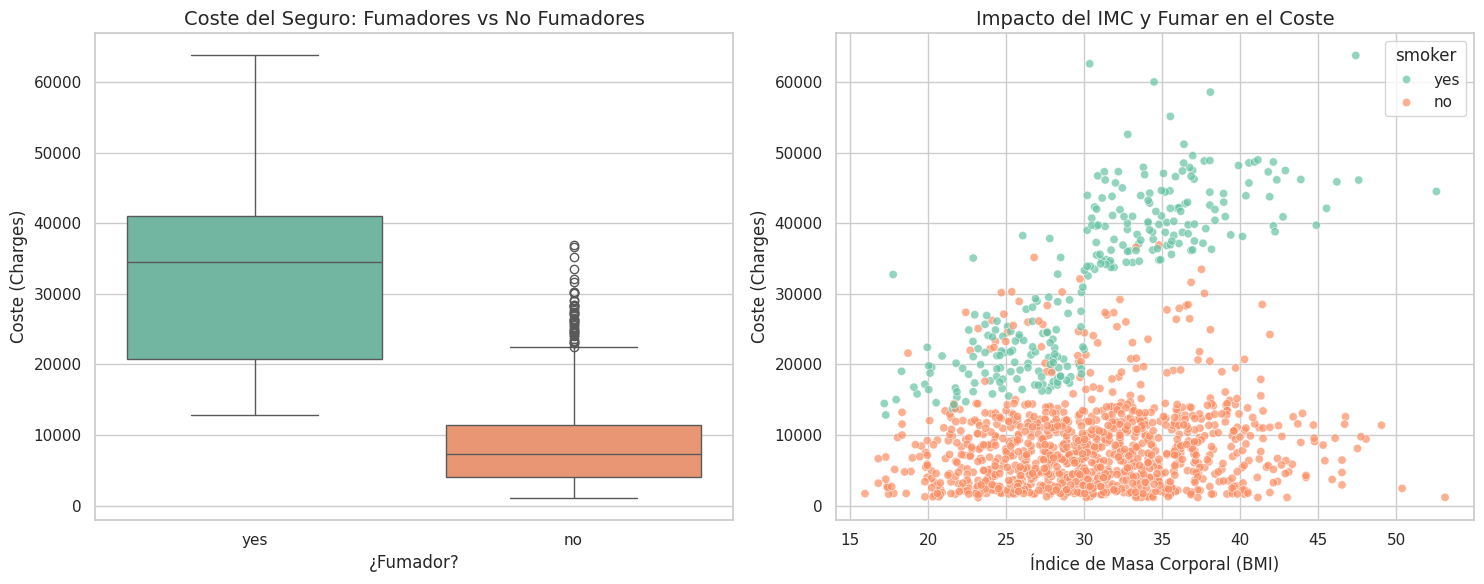

In [5]:
# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Crear una figura con dos gráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: ¿Cómo afecta fumar al precio?
sns.boxplot(data=df, x='smoker', y='charges', ax=axes[0], palette='Set2')
axes[0].set_title('Coste del Seguro: Fumadores vs No Fumadores', fontsize=14)
axes[0].set_xlabel('¿Fumador?')
axes[0].set_ylabel('Coste (Charges)')

# Gráfico 2: Relación entre IMC (bmi), Coste y si fuma
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', ax=axes[1], palette='Set2', alpha=0.7)
axes[1].set_title('Impacto del IMC y Fumar en el Coste', fontsize=14)
axes[1].set_xlabel('Índice de Masa Corporal (BMI)')
axes[1].set_ylabel('Coste (Charges)')

plt.tight_layout()
plt.show()

### Smoking, BMI, and Insurance Charges

The plots show that **smoking status has a strong impact on insurance charges**. In the boxplot, smokers have a much higher median cost and a wider spread of values than non-smokers, indicating both **higher typical expenses** and **greater variability**.

The scatter plot also suggests that **BMI is positively related to charges**, especially among smokers. As BMI increases, insurance costs tend to rise more sharply for smokers than for non-smokers. This indicates that the combination of **smoking and higher BMI** is associated with the highest insurance charges in the dataset.

## Data Preprocessing

Before training the models, the dataset must be transformed into a format suitable for machine learning algorithms. First, categorical variables are converted into numerical features using **one-hot encoding**. Then, the data is split into **training, validation, and test sets**, ensuring that the proportion of smokers is preserved across each subset through **stratified sampling**. Finally, the input features are standardized so that the models, especially neural networks, can learn more effectively from variables that share a similar scale.

In [10]:

# ---------------------------------------------------------
# 1. ONE-HOT ENCODING (Texto a Números)
# ---------------------------------------------------------
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# ---------------------------------------------------------
# 2. SEPARAR X (Características) e y (Objetivo)
# ---------------------------------------------------------
X = df_encoded.drop('charges', axis=1) # Todo menos el precio
y = df_encoded['charges']              # Solo el precio

# ---------------------------------------------------------
# 3. DIVIDIR LOS DATOS ESTRATIFICANDO POR FUMADORES (El truco PRO)
# ---------------------------------------------------------
# Separamos el 20% para el examen final (Test). Estratificamos usando la columna 'smoker_yes'
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df_encoded['smoker_yes']
)

# Del 80% restante, sacamos otro 20% para Validación. Volvemos a estratificar.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=X_temp['smoker_yes']
)

# ---------------------------------------------------------
# 4. ESCALAR LOS DATOS (Normalización)
# ---------------------------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Entrenamiento: {X_train_scaled.shape[0]} pacientes")
print(f"Validación: {X_val_scaled.shape[0]} pacientes")
print(f"Test: {X_test_scaled.shape[0]} pacientes")

print("\n--- ASÍ VE LOS DATOS LA RED NEURONAL ---")
display(pd.DataFrame(X_train_scaled, columns=X.columns).head(3))

Entrenamiento: 856 pacientes
Validación: 214 pacientes
Test: 268 pacientes

--- ASÍ VE LOS DATOS LA RED NEURONAL ---


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-0.492271,2.542151,0.713327,0.965546,-0.506927,-0.544949,1.616111,-0.571954
1,1.430880,-0.679287,1.530741,-1.035683,-0.506927,1.835033,-0.618769,-0.571954
2,-0.064904,-0.467340,1.530741,-1.035683,-0.506927,-0.544949,-0.618769,1.748391


## We create the Random Forest Model

In [11]:
# 1. Crear y entrenar el modelo Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 2. Hacer predicciones en el set de Test (el examen final)
rf_predictions = rf_model.predict(X_test_scaled)

# 3. Evaluar el modelo
mae = mean_absolute_error(y_test, rf_predictions)
r2 = r2_score(y_test, rf_predictions)

print("--- RESULTADOS DEL MODELO BASE (RANDOM FOREST) ---")
print(f"Error Absoluto Medio (MAE): ${mae:.2f}")
print(f"R2 Score (Precisión): {r2:.4f}")


--- RESULTADOS DEL MODELO BASE (RANDOM FOREST) ---
Error Absoluto Medio (MAE): $2882.68
R2 Score (Precisión): 0.8467


In [12]:
# 1. Configurar el dispositivo (como en el Quickstart)
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Convertir tus arrays de Sklearn a Tensores de PyTorch
# Usamos float32 porque es lo que esperan las capas nn.Linear
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1).to(device)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1).to(device)

# 3. Crear los DataLoaders (Lotes de 32 para no saturar)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32)

print(f"Datos listos en {device}. Tenemos {X_train_t.shape[1]} variables de entrada.")
class InsuranceModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        # Estructura de capas (Stack)
        self.main_stack = nn.Sequential(
            nn.Linear(input_size, 64), # Capa de entrada
            nn.ReLU(),                 # Activación
            nn.Linear(64, 32),         # Capa oculta
            nn.ReLU(),
            nn.Linear(32, 1)           # Salida (1 solo número: el precio)
        )

    def forward(self, x):
        return self.main_stack(x)

# Instanciamos el modelo
model = InsuranceModel(X_train_t.shape[1]).to(device)

# Loss: MSE | Optimizer: Adam 
loss_fn = nn.MSELoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

Datos listos en cpu. Tenemos 8 variables de entrada.
InsuranceModel(
  (main_stack): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [13]:
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    for X, y in dataloader:
        pred = model(X)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

def test_loop(dataloader, model, loss_fn):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            total_loss += loss_fn(pred, y).item()
    return total_loss / len(dataloader)

# Lanzamos 100 vueltas
epochs = 100
for t in range(epochs):
    train_loop(train_loader, model, loss_fn, optimizer)
    if (t+1) % 10 == 0:
        val_loss = test_loop(val_loader, model, loss_fn)
        print(f"Época {t+1} - MSE Validación: {val_loss:.2f}")

print("¡Entrenamiento completado!")

Época 10 - MSE Validación: 294337428.57
Época 20 - MSE Validación: 253654006.86
Época 30 - MSE Validación: 171971202.29
Época 40 - MSE Validación: 93318468.57
Época 50 - MSE Validación: 50958879.43
Época 60 - MSE Validación: 36459515.14
Época 70 - MSE Validación: 32946064.86
Época 80 - MSE Validación: 32317023.71
Época 90 - MSE Validación: 32207863.14
Época 100 - MSE Validación: 32211676.29
¡Entrenamiento completado!
